# Is Fandango's Movie Rating System fixed?

## Context

[Fandango](https://www.fandango.com/) is a digital network, serving visitors with movie information and rating, ticketing, trailers and original video, home entertainment and fan merchandise. For movie rating, Fandango uses a 5-star system on their website, where the minimum rating is 0 stars and the maximum is 5 stars.

In October 2015, a data journalist Walt Hickey conducted movie rating data analysis (published in this article) and found a significant discrepancy between the number of stars displayed to users and the actual rating in the HTML of the page, which can suggest that Fandango's rating system was biased and dishonest. According to his analysis, the actual rating was almost always rounded up to the nearest half-star, the actual half-star rating – up to the nearest whole star, and on one occasion, a movie rating was even rounded up by an entire star, from 4 to 5.

In [61]:
![]

Investigating Fandango Movie Ratings.ipynb
download.png
fandango_score_comparison.csv
movie_ratings_16_17.csv


This graph, taken from Hickey's article, shows actual and displayed movie ratings, with relative frequency in percentage for each unique rating. Both distributions are strongly left skewed, suggesting that movie ratings on Fandango are generally high to very high. Moreover, the displayed rating distribution is clearly shifted to the right compared to the actual rating distribution, suggesting strongly that Fandango inflates the ratings under the hood.

The official reply from Fandango was that the biased rounding was not intentional but caused by a bug in their system, which was supposed to be fixed as soon as possible. Presumably, this has already happened, although we can't tell for sure since the actual rating value doesn't seem to be displayed anymore in their pages' HTML

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
fandango_before = pd.read_csv('fandango_score_comparison.csv')
fandango_after = pd.read_csv('movie_ratings_16_17.csv')

fandango_before.head(3)

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Fandango_Stars,Fandango_Ratingvalue,RT_norm,RT_user_norm,...,IMDB_norm,RT_norm_round,RT_user_norm_round,Metacritic_norm_round,Metacritic_user_norm_round,IMDB_norm_round,Metacritic_user_vote_count,IMDB_user_vote_count,Fandango_votes,Fandango_Difference
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,5.0,4.5,3.70,4.3,...,3.90,3.5,4.5,3.5,3.5,4.0,1330,271107,14846,0.5
1,Cinderella (2015),85,80,67,7.5,7.1,5.0,4.5,4.25,4.0,...,3.55,4.5,4.0,3.5,4.0,3.5,249,65709,12640,0.5
2,Ant-Man (2015),80,90,64,8.1,7.8,5.0,4.5,4.00,4.5,...,3.90,4.0,4.5,3.0,4.0,4.0,627,103660,12055,0.5


In [25]:
fandango_before.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Fandango_Stars              146 non-null    float64
 7   Fandango_Ratingvalue        146 non-null    float64
 8   RT_norm                     146 non-null    float64
 9   RT_user_norm                146 non-null    float64
 10  Metacritic_norm             146 non-null    float64
 11  Metacritic_user_nom         146 non-null    float64
 12  IMDB_norm                   146 non-null    float64
 13  RT_norm_round               146 non

In [26]:
fandango_before.columns

Index(['FILM', 'RottenTomatoes', 'RottenTomatoes_User', 'Metacritic',
       'Metacritic_User', 'IMDB', 'Fandango_Stars', 'Fandango_Ratingvalue',
       'RT_norm', 'RT_user_norm', 'Metacritic_norm', 'Metacritic_user_nom',
       'IMDB_norm', 'RT_norm_round', 'RT_user_norm_round',
       'Metacritic_norm_round', 'Metacritic_user_norm_round',
       'IMDB_norm_round', 'Metacritic_user_vote_count', 'IMDB_user_vote_count',
       'Fandango_votes', 'Fandango_Difference'],
      dtype='object')

We see that the fandango_before dataframe contains 146 entries (films) and 22 columns, representing ratings from different sources for each film (Rotten Tomatoes, Metacritic, IMDB, Fandango) and user vote counts. There are no missing values in the dataframe.

Now, lets take a look at the fandango_after dataframe:

In [27]:
fandango_after.head(3)

,movie,year,metascore,imdb,tmeter,audience,fandango,n_metascore,n_imdb,n_tmeter,n_audience,nr_metascore,nr_imdb,nr_tmeter,nr_audience
0,10 Cloverfield Lane,2016,76,7.2,90,79,3.5,3.80,3.60,4.5,3.95,4.0,3.5,4.5,4.0
1,13 Hours,2016,48,7.3,50,83,4.5,2.40,3.65,2.5,4.15,2.5,3.5,2.5,4.0
2,A Cure for Wellness,2016,47,6.6,40,47,3.0,2.35,3.30,2.0,2.35,2.5,3.5,2.0,2.5


In [28]:
fandango_after.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie         214 non-null    object 
 1   year          214 non-null    int64  
 2   metascore     214 non-null    int64  
 3   imdb          214 non-null    float64
 4   tmeter        214 non-null    int64  
 5   audience      214 non-null    int64  
 6   fandango      214 non-null    float64
 7   n_metascore   214 non-null    float64
 8   n_imdb        214 non-null    float64
 9   n_tmeter      214 non-null    float64
 10  n_audience    214 non-null    float64
 11  nr_metascore  214 non-null    float64
 12  nr_imdb       214 non-null    float64
 13  nr_tmeter     214 non-null    float64
 14  nr_audience   214 non-null    float64
dtypes: float64(10), int64(4), object(1)
memory usage: 25.2+ KB


In [29]:
fandango_after.columns

Index(['movie', 'year', 'metascore', 'imdb', 'tmeter', 'audience', 'fandango',
       'n_metascore', 'n_imdb', 'n_tmeter', 'n_audience', 'nr_metascore',
       'nr_imdb', 'nr_tmeter', 'nr_audience'],
      dtype='object')

The fandango_after dataframe has 214 entries (films) and 15 columns, representing the release year of the movie, critic and/or user ratings from the Rotten Tomatoes, Metacritic, IMDB, and Fandango. Also in this dataframe there are no missing values.

Our next step in the data understanding process will be to define the <b>population of interest</b> for our project's goal.

First, we want to figure out whether the two samples are representative for the population we're trying to describe. For this purpose, we have consulted the corresponding README.md files of both repositories and also Hickey's article.

We found out that for <b>each dataset different sampling criteria were used</b>.



The dataset before the analysis contains only the movies that at the time of sampling (Aug. 24, 2015) have had:

* a Rotten Tomatoes rating, an RT User rating, a Metacritic score, a Metacritic User score, and an IMDb score,
* at least 30 fan reviews on Fandango,
* tickets on sale in 2015.


The dataset after the analysis contains only the movies that are:

* the most popular ones, with a significant number of votes (but it's not specified in the file what "significant" means in this context),
* released in 2016 and 2017.

This means that the sampling process in both cases was more selective rather than random, and <b>not all the movies had an equal chance to be included in the two samples</b>. Hence, the resulting samples are very unlikely to be representative of the entire population of interest.

At this point, we can decide or to collect new data, or to tweak the goal of our analysis so that to change the population of interest and make the available samples representative. The second approach looks much faster and, in general, more realistic, so let's hold to it.

## Project Goal Tweak

Our initial goal, as stated in the introduction, was to analyze more recent movie ratings data and determine whether there has been any change in Fandango's rating system after Hickey's analysis. Introducing changes to this statement, we have to keep in mind that the modified goal has still to be its fairly good proxy.

We see that in both samples the selected movies are somehow the popular ones (even though the quantitive definition of popularity for them differs), and have ratings from the same review sources, including Rotten Tomatoes, Metacritic, IMDB, and Fandango (for now, we'll be interested only in Fandango's ratings). The dataset before the analysis (the fandango_before dataframe) is related to 2015, while the one after the analysis (fandango_after) – to 2016 and 2017. We can decide to exclude the data for 2017 from the second dataset and compare only the year before the analysis (2015) and the year after (2016). In this way, our new project goal is <b>to analyze popular movie ratings for 2015 and determine whether Fandango changed their rating system for popular movies in 2016</b>.

## Cleaning data

* With the goal of the project updated now we only need to keep data from year 2015 in the "before fandango" dataset and from year 2016 from the "after fandango" dataset.
* "before fandango" dataset has data only for movies which has atleast 30 reviews on Fandango but the "after fandango" dataset states that it contains movies with "significant" number of reviews. The exact number is not specified. So we can filter the dataset to contain only movies with 30 or more reviews on Fandango.

In [30]:
# before dataset has year values embedded with the movie name in the 'FILM' column
fandango_before['year'] = fandango_before['FILM'].str[-5:-1]
fandango_before['year'].value_counts(normalize=True)*100

2015    88.356164
2014    11.643836
Name: year, dtype: float64

We can see that 11.65% of the movies from the 'fandango_before' dataset are from 2014 and we can get rid of them.

In [31]:
fandango_before = fandango_before[fandango_before['year']=='2015']
fandango_before['year'].unique()

array(['2015'], dtype=object)

In [32]:
# after dataset has the year value given to us directly
fandango_after['year'].value_counts(normalize=True)*100

2016    89.252336
2017    10.747664
Name: year, dtype: float64

In [33]:
# lets get rid of 2017 movies from the after dataset
fandango_after = fandango_after[fandango_after['year']==2016]
fandango_after['year'].unique()

array([2016])

`fandango_before` dataset contains movies with atleast 30 reviews on Fandango, lets verify that first then we look at the `fandango_after` dataset

In [35]:
len(fandango_before[fandango_before['Fandango_votes'] >= 30])==len(fandango_before)

True

`fandango_after` dataset has no information about the count of fan ratings on Fandango. As a work around, I sample from the dataset and check there ratings on Fandango's website .If 80-90% of the samples meet the criteria of having more that 30 reviews then we can assume that the sample is representative of our target population.

In [36]:
fandango_after.sample(10, random_state=1000)

,movie,year,metascore,imdb,tmeter,audience,fandango,n_metascore,n_imdb,n_tmeter,n_audience,nr_metascore,nr_imdb,nr_tmeter,nr_audience
193,The Secret Life of Pets,2016,61,6.6,74,63,4.0,3.05,3.30,3.70,3.15,3.0,3.5,3.5,3.0
136,Resident Evil: The Final Chapter,2016,49,5.8,33,58,4.0,2.45,2.90,1.65,2.90,2.5,3.0,1.5,3.0
208,Why Him?,2016,39,6.4,40,57,4.0,1.95,3.20,2.00,2.85,2.0,3.0,2.0,3.0
172,The Duel,2016,42,5.7,22,30,3.5,2.10,2.85,1.10,1.50,2.0,3.0,1.0,1.5
174,The Finest Hours,2016,58,6.8,63,66,4.0,2.90,3.40,3.15,3.30,3.0,3.5,3.0,3.5
130,Patriots Day,2016,69,7.5,80,88,4.5,3.45,3.75,4.00,4.40,3.5,4.0,4.0,4.5
198,The Whole Truth,2016,46,6.1,29,33,3.0,2.30,3.05,1.45,1.65,2.5,3.0,1.5,1.5
158,The 9th Life of Louis Drax,2016,41,6.3,40,34,3.5,2.05,3.15,2.00,1.70,2.0,3.0,2.0,1.5
71,Hunt for the Wilderpeople,2016,81,7.9,97,91,4.5,4.05,3.95,4.85,4.55,4.0,4.0,5.0,4.5
184,The Legend of Tarzan,2016,44,6.3,36,60,4.5,2.20,3.15,1.80,3.00,2.0,3.0,2.0,3.0


Looking at the movies on Fandango's website we find the following information

* Bad Santa 2                                      - 10,000+       
* Genius                                           - 2,500+        
* I.T.                                             - 250+          
* Gold                                             - 5,000+        
* Moonlight                                        - 25,000+       
* Florence Foster Jenkins                          - 10,000+       
* The Bye Bye Man                                  - 5,000+        
* Office Christmas Party                           - 10,000+       
* The Forest                                       - 10,000+       
* Crouching Tiger, Hidden Dragon: Sword of Destiny - 10,000+       

Each movie has much more reviews(a lot more actually) than 30, so we can assume that dataset is representative of our target population.

## Comparing distributions of 2015 and 2016

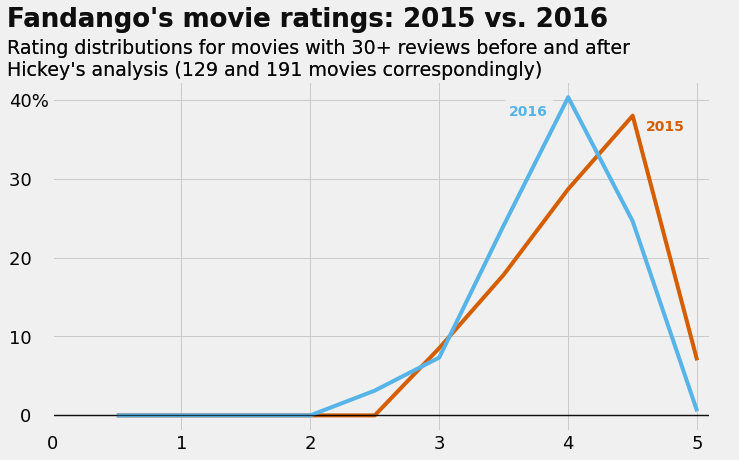

In [48]:
plt.style.use('fivethirtyeight')

# Creating a list of colorblind-friendly colors
colors = [[213/255,94/255,0],        # vermillion
          [86/255,180/255,233/255],  # sky blue
          [230/255,159/255,0],       # orange
          [0,158/255,115/255],       # bluish green
          [204/255,121/255,167/255], # reddish purple
          [0,114/255,178/255]]       # blue

# Defining a function for improving plot aesthetics and reproducing the FiveThirtyEight style
def add_plot_aesthetics(ax, y_ticks, y_ticklabels, y_line,
                        x_start, x_end,
                        x_title, y_title, title,
                        x_subtitle, y_subtitle, subtitle):
    ax.tick_params(axis='both', labelsize=18)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticklabels)
    ax.axhline(y_line, color='black', linewidth=1.3, alpha=0.7)
    ax.set_xlim(x_start, x_end)
    ax.text(x_title, y_title, s=title,
            fontsize=26, weight='bold', alpha=0.75)
    ax.text(x_subtitle, y_subtitle, s=subtitle,
            fontsize=19, alpha=0.85)
    return ''

#  Creating plots for comparing the movie rating distribution shapes for 2015 and 2016
fig, ax = plt.subplots(figsize=(10.5,6))

# Creating lists of dataframes, columns with Fandango's ratings, and years
dfs = [fandango_before, fandango_after]
columns = ['Fandango_Stars', 'fandango']
labels = ['2015', '2016']

for i in range(len(dfs)):
    # Creating a relative frequency table (in %) for given column sorted by rating
    ratings = dfs[i][columns[i]].value_counts(normalize=True).sort_index()*100
    
    # Adding missing unique ratings from 0.5 to 5 (in our case – low ratings) and assigning 0 to their frequencies
    ratings_arranged = pd.Series(ratings, index=np.arange(0.5,5.1,0.5).tolist()).fillna(0)
    
    ax = ratings_arranged.plot(label=labels[i], c=colors[i])
    
    add_plot_aesthetics(ax=ax, y_ticks=(0, 10, 20, 30, 40),
                        y_ticklabels=('0   ', '10   ', '20   ', '30   ', '40%'), y_line=0,
                        x_start=0, x_end=5.1,
                        x_title=-0.35, y_title=49.2,
                        title='Fandango\'s movie ratings: 2015 vs. 2016',
                        x_subtitle=-0.35, y_subtitle=43,
                        subtitle='Rating distributions for movies with 30+ reviews before and after\
                 \nHickey\'s analysis (129 and 191 movies correspondingly)')
    
    # Adding annotations to the plots
    ax.text(x=4.6, y=36,
            s='2015',
            color=colors[0],
            weight='bold',
            backgroundcolor='#f0f0f0')
    ax.text(x=3.54, y=38,
            s='2016',
            color=colors[1],
            weight='bold',
            backgroundcolor='#f0f0f0')
    
plt.show()    

For the plot we can notice the following changes:
* Both distributions are left-skewed but the one for 2016 is left skewed
* Mode for 2016 has decresed to 4 from 4.5 in 2015
* Minimum rating has decreased from 2.5 in 2015 to 2 in 2016
* Less movies have been rated the highest values of 5 and 4.5 in 2016

These observations suggest that after the article Fandango's rating system was really changed, and the movies in 2016 were rated slightly lower, towards more realistic values, compared to 2015.

## Direction of change

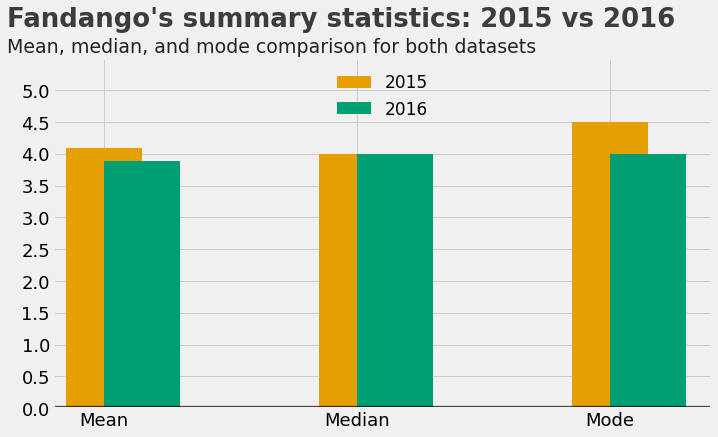

In [54]:
rating_columns = [fandango_before['Fandango_Stars'], fandango_after['fandango']]
list_of_stats = []
for item in rating_columns:
    stats = [item.mean(), item.median(), item.mode().loc[0]]
    list_of_stats.append(stats)
    
df_stats = pd.DataFrame(list_of_stats, columns=["Mean","Median","Mode"], index=['2015', '2016'])
fig, ax = plt.subplots(figsize = (10.5,6))
ax = df_stats.loc['2015'].plot.bar(color=colors[2],
                                      align='center',
                                      label='2015',
                                      width=0.3)
ax = df_stats.loc['2016'].plot.bar(color=colors[3],
                                      align='edge',
                                      label='2016',
                                      width=0.3,
                                      rot=0)

add_plot_aesthetics(ax=ax, y_ticks=np.arange(0,5.1,.5),
                    y_ticklabels=np.arange(0,5.1,.5).tolist(), y_line=0.03,
                    x_start=-0.2, x_end=2.4,
                    x_title=-0.383, y_title=6,
                    title='Fandango\'s summary statistics: 2015 vs 2016',
                    x_subtitle=-0.383, y_subtitle=5.6,
                    subtitle='Mean, median, and mode comparison for both datasets')
# Adding case-specific plot aesthetics
ax.set_ylim(0,5.5)
ax.legend(frameon=0, loc='upper center', fontsize=17)

plt.show()

We can observe the following changes in rating summary statistics:

* The mean has decreased by around 5% with respect to the one before the article.
* The median has remained the same.
* The mode has dropped by 0.5 points.

These results confirm once again that <b>Fandango's rating system</b> has been improved and become less biased after Hickey's analysis, even though the <b>difference doesn't look something significant</b>.

## Comparing Different Movie Rating Aggregators

Although we can see that Fandango's rating system has improved but still the distribution of ratings seems pretty high on their website. Lets compare Fandango with other movie rating providers like IMDB, Metacritic and Rotten Tomatoes.

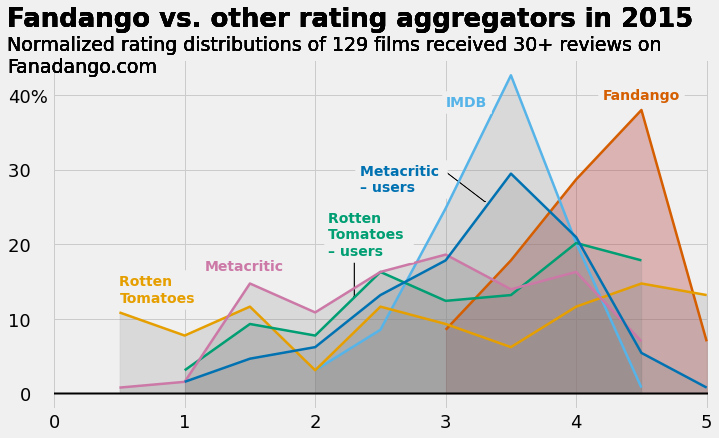

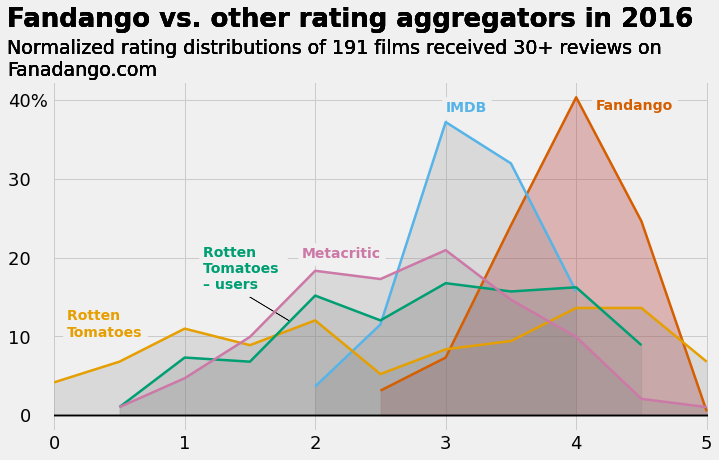

In [56]:
# Defining a function for plotting different aggregator distributions
def plot_aggregator_distributions(df, columns, column_fandango,
                                  year, n_films,
                                  x_annotations, y_annotations,
                                  n_arrows, x_arrow, y_arrow, dx_arrow, dy_arrow):
    fig, ax = plt.subplots(figsize=(10.5,6))
    labels = ['Fandango', 'IMDB', 'Rotten \nTomatoes', 'Rotten \nTomatoes \n– users',
             'Metacritic', 'Metacritic \n– users']
    
    for i in range(len(columns)):
        
        # Creating a relative frequency table (in %) for given column sorted by rating
        ratings = df[columns[i]].value_counts(normalize=True).sort_index()*100
        
        # Plotting the resulting Series
        ax = ratings.plot(linewidth=2.5, c=colors[i])
        
        # Filling the area under the plots with colors, emphasizing Fandango
        if columns[i]==column_fandango:
            ax.fill_between(ratings.index.tolist(), ratings.tolist(), alpha=0.2, color='red')
        ax.fill_between(ratings.index.tolist(), ratings.tolist(), alpha=0.2, color='grey')
        
        # Adding an annotation to each graph
        ax.text(x=x_annotations[i], y=y_annotations[i],
                s=labels[i], color=colors[i],
                weight='bold', backgroundcolor='#f0f0f0')
        
        add_plot_aesthetics(ax, y_ticks=(0, 10, 20, 30, 40),
                        y_ticklabels=('0   ', '10   ', '20   ', '30   ', '40%'), y_line=0,
                        x_start=-0.02, x_end=5.02,
                        x_title=-0.36, y_title=49.2,
                        title=f'Fandango vs. other rating aggregators in {year}',
                        x_subtitle=-0.36, y_subtitle=43,
                        subtitle=f'Normalized rating distributions of {n_films} films received 30+ reviews on \nFanadango.com')
        # Adding arrows
    for j in range(n_arrows):
        ax.arrow(x=x_arrow[j], y=y_arrow[j],
                 dx=dx_arrow[j], dy=dy_arrow[j],
                 width=0.005, fc='k', ec='k')
        
    plt.show()
    
    
# Plotting different aggregator distributions for 2015
plot_aggregator_distributions(df=fandango_before,
                              columns=['Fandango_Stars', 'IMDB_norm_round', 'RT_norm_round',
                                       'RT_user_norm_round', 'Metacritic_norm_round',
                                       'Metacritic_user_norm_round'], 
                              column_fandango='Fandango_Stars',
                              year=2015, n_films = 129,
                              x_annotations=[4.2, 3, 0.5, 2.1, 1.15, 2.34],
                              y_annotations=[39.5, 38.5, 12.3, 18.6, 16.5, 27.15],
                              n_arrows=2, x_arrow=[3,2.3], y_arrow=[29.7,18],
                              dx_arrow=[0.3,0], dy_arrow=[-4,-5])        

# Plotting different aggregator distributions for 2016
plot_aggregator_distributions(df=fandango_after,
                              columns=['fandango', 'nr_imdb', 'nr_tmeter', 'nr_audience',
                                       'nr_metascore'], column_fandango='fandango',
                              year=2016, n_films = 191,
                              x_annotations=[4.15, 3, 0.1, 1.14, 1.9],
                              y_annotations=[38.7, 38.5, 10, 16, 20],
                              n_arrows=1, x_arrow=[1.5], y_arrow=[15],
                              dx_arrow=[0.3], dy_arrow=[-3])
plt.show()

We can definitely say that <b>Fandango's rating distribution is significantly different</b> from those of the other aggregators both before and after the article. It means that already the actual ratings in their pages' HTML were hugely inflated, probably because of some specific approach for gathering ratings, or an intentional filtering, but doesn't look to be just a "system bug". After Hickey's analysis, Fandango's rating distribution has slightly shifted to the left, becoming less left skewed. However, with respect to the other aggregators, it still looks totally unrealistic and, hence, unreliable.

Instead, as for the <b>most reliable aggregator for checking a movie rating, it results to be Metacritic</b> (expert scores), since its rating distribution shape resembles a normal distribution most of all.

## Summary statistics of all aggregators

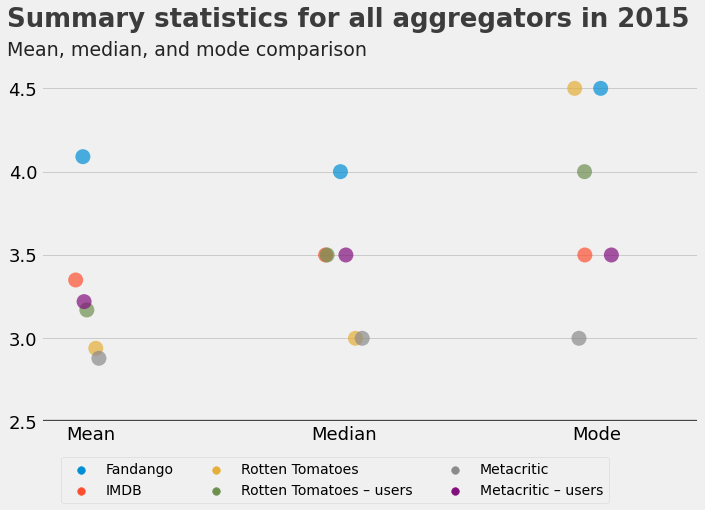

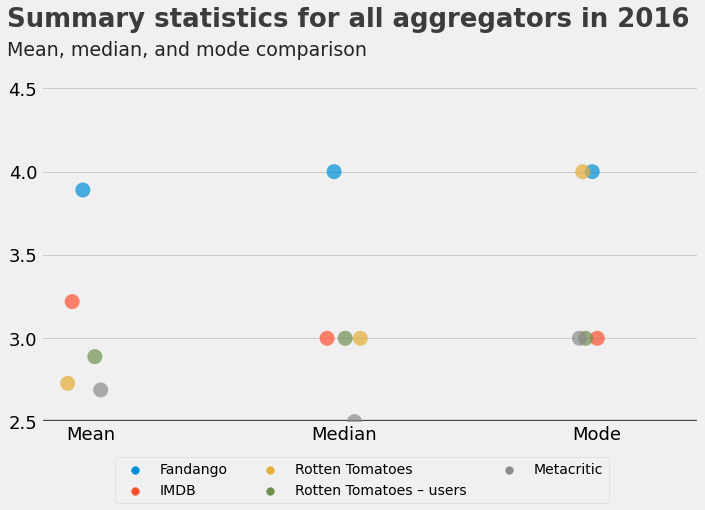

In [58]:
# Defining a function for plotting different aggregator summary statistics
def plot_aggregator_stats(df, columns, labels, year):
    
    # Creating a list of summary statistics for all aggregators' rating columns
    list_sum_stat = []
    rating_columns = []
    for i in range(len(columns)):
        rating_columns.append(df[columns[i]])
        lst = [labels[i],
               round(rating_columns[i].mean(),2),
               rating_columns[i].median(),
               rating_columns[i].mode().loc[0]]
        list_sum_stat.append(lst)
        
    # Creating a dataframe from the list of summary statistics
    df_sum_stat = pd.DataFrame(list_sum_stat, columns=['Aggregator', 'Mean', 'Median', 'Mode'])
    
    # Melting the dataframe for further plotting
    melted = pd.melt(df_sum_stat, id_vars=['Aggregator'], value_vars=['Mean', 'Median', 'Mode'])

    
    # Creating a strip plot for the summary statistics
    fig,ax = plt.subplots(figsize=(10.5,6))
    ax = sns.stripplot(x = 'variable', y = 'value', hue='Aggregator',
                       s=15, alpha=0.7, data = melted)
    
    # Adding plot aesthetics according to the FiveThirtyEight style
    add_plot_aesthetics(ax, y_ticks=np.arange(0,5.1,.5), y_ticklabels=np.arange(0,5.1,.5).tolist(),
                        y_line=2.51,
                        x_start=-0.2, x_end=2.4,
                        x_title=-0.332, y_title=4.87,
                        title=f'Summary statistics for all aggregators in {year}',
                        x_subtitle=-0.332, y_subtitle=4.7,
                        subtitle='Mean, median, and mode comparison')
   
    # Adding case-specific plot aesthetics
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.set_ylim(2.5,4.6)
    ax.legend(fontsize=14, bbox_to_anchor=(0.875,-0.08), ncol=3)
    
    plt.show()
    return ''
    
# Plotting different aggregator summary statistics for 2015
plot_aggregator_stats(df=fandango_before,
                      columns=['Fandango_Stars', 'IMDB_norm_round', 'RT_norm_round',
                               'RT_user_norm_round', 'Metacritic_norm_round',
                               'Metacritic_user_norm_round'],
                      labels=['Fandango', 'IMDB', 'Rotten Tomatoes',
                              'Rotten Tomatoes – users', 'Metacritic', 'Metacritic – users'],
                      year=2015)

# Plotting different aggregator summary statistics for 2016
plot_aggregator_stats(df=fandango_after,
                      columns=['fandango', 'nr_imdb', 'nr_tmeter', 'nr_audience',
                               'nr_metascore'],
                      labels=['Fandango', 'IMDB', 'Rotten Tomatoes',
                              'Rotten Tomatoes – users', 'Metacritic'],
                      year=2016)
plt.show()

Not surprisingly, we see that all the summary statistics are evidently higher for Fandango both in 2015 and 2016, with the only exception for Rotten Tomatoes that reached Fandango with its mode value.

## Conclusion


In this project, we have analyzed Fandango’s and other aggregators’ ratings for popular movies with at least 30 fan reviews on www.fandango.com before Hickey’s article in 2015, to determine whether Fandango was still inflating ratings the year after. Here are our main insights:

* Actual ratings in Fandango’s HTML were hugely inflated, presumably because of some specific approach for gathering ratings, or an intentional filtering but given that Fandango also sells tickets, it doesn't look to be just a "system bug".
* The shapes of Fandango’s movie rating distributions for both 2015 and 2016 are strongly left skewed, but the one for 2016 is a bit less skewed.
* The summary statistics: the mean and the mode have decreased insignificantly, while the median remained the same.
* In 2016, there were less movies with the highest Fandango’s ratings 5 and 4.5, and appeared very few movies with the rating 2.5, while in 2015, the minimum was 3. In both cases, the predominant majority of movies are rated from 3.5 to 4.5.
* From a wider prospective, even if in 2016 Fandango's rating distribution has slightly shifted to the left, towards more realistic values, it still looks totally unrealistic with respect to the other aggregators. In addition, all the summary statistics are evidently higher for Fandango both in 2015 and 2016.
* The most reliable aggregator for checking a movie rating is Metacritic (expert scores), because of its almost normal distribution shape.
* <b>Main conclusion</b>: Fandango's rating system has been insignificantly improved in 2016, but remained rather biased anyway.